# Day 3: Linear algebra 2: matrices

**Thu, Oct 8 · Prep · about 45 minutes**

Quantum gates are matrices, and running a gate means multiplying the state vector by that matrix.

**By the end of this notebook you can:**
- Multiply a matrix by a vector and by another matrix
- See a 2×2 matrix as a transformation of the plane
- Compute the conjugate transpose A†

> How to use this notebook: read each explanation, run the cell under it, then change the numbers and run it again.
> The exercises at the end have a "your turn" cell and a hidden worked solution. Try first, then check.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (5, 5), "axes.grid": True, "grid.alpha": 0.3})

def tex(label):
    """Typeset a ket label like '|+>' as a proper |+⟩ in plots."""
    if label.startswith("|") and label.endswith(">"):
        return r"$|" + label[1:-1] + r"\rangle$"
    return label

## 1. Matrix times vector
Each output entry is a row of the matrix dotted with the vector:

```
[a b] [x]   [a·x + b·y]
[c d] [y] = [c·x + d·y]
```

In [2]:
A = np.array([[2, 1],
              [0, 1]])
x = np.array([1, 2])
print("A @ x =", A @ x)

A @ x = [4 2]


## 2. A matrix is a transformation
Apply a matrix to every corner of the unit square and you see what it does to the whole plane.
The columns of the matrix are where e₀ and e₁ land.

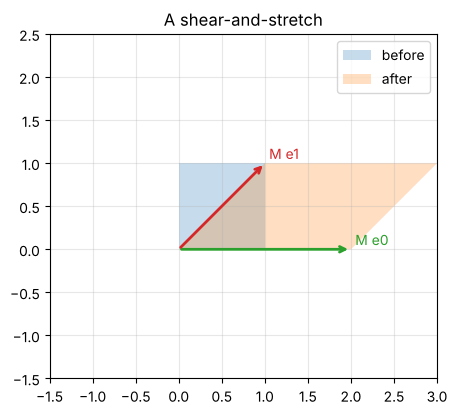

In [3]:
def show_transform(M, title):
    sq = np.array([[0, 1, 1, 0, 0], [0, 0, 1, 1, 0]])
    out = M @ sq
    fig, ax = plt.subplots()
    ax.fill(sq[0], sq[1], alpha=0.25, label="before")
    ax.fill(out[0], out[1], alpha=0.25, label="after")
    for col, c in [(0, "C2"), (1, "C3")]:
        ax.annotate("", xy=M[:, col], xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
        ax.text(*(M[:, col] + 0.05), f"M e{col}", color=c)
    ax.set_xlim(-1.5, 3); ax.set_ylim(-1.5, 2.5); ax.set_aspect("equal"); ax.legend(); ax.set_title(title)
    plt.show()

show_transform(np.array([[2, 1], [0, 1]]), "A shear-and-stretch")

### The X matrix swaps the axes
X = [[0, 1], [1, 0]] is the quantum NOT gate. It sends e₀ to e₁ and e₁ to e₀, which is a reflection across the line y = x.

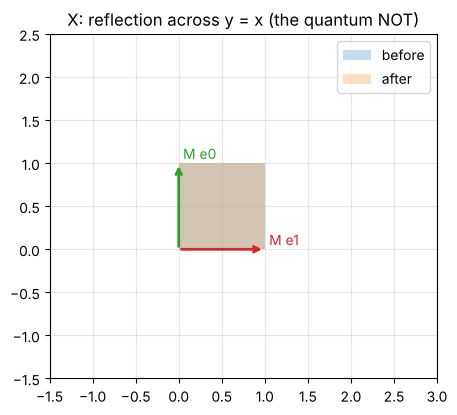

X @ [1, 0] = [0 1]    X @ [0, 1] = [1 0]


In [4]:
X = np.array([[0, 1], [1, 0]])
show_transform(X, "X: reflection across y = x (the quantum NOT)")
print("X @ [1, 0] =", X @ np.array([1, 0]), "   X @ [0, 1] =", X @ np.array([0, 1]))

## 3. Matrix times matrix = doing one transformation after another
(AB)x means "apply B first, then A". Order matters: in general AB ≠ BA.
In circuits, applying gate G1 then G2 corresponds to the product G2·G1, so read matrix products right to left.

In [5]:
Z = np.array([[1, 0], [0, -1]])
print("XZ =\n", X @ Z)
print("ZX =\n", Z @ X)
print("Same? ", np.array_equal(X @ Z, Z @ X))

XZ =
 [[ 0 -1]
 [ 1  0]]
ZX =
 [[ 0  1]
 [-1  0]]
Same?  False


## 4. Identity, transpose and conjugate transpose (†)
- **Identity** I leaves every vector alone.
- **Transpose** Aᵀ swaps rows and columns.
- **Conjugate transpose** A† (read "A dagger") = transpose and conjugate every entry. In NumPy: `A.conj().T`.

A† is everywhere in quantum computing: a gate U is valid exactly when U†U = I (Day 8).

In [6]:
A = np.array([[1, 1j],
              [2, 3 - 1j]])
print("A^T =\n", A.T)
print("A-dagger =\n", A.conj().T)

A^T =
 [[1.+0.j 2.+0.j]
 [0.+1.j 3.-1.j]]
A-dagger =
 [[1.-0.j 2.-0.j]
 [0.-1.j 3.+1.j]]


## Exercises
**E1.** Compute X·(a, b) by hand for X = [[0, 1], [1, 0]].

**E2.** Find A† for A = [[1, i], [2, 3 − i]].

**E3.** Check that X·X = I. What does that mean physically?

In [7]:
# Your turn

<details>
<summary><b>Show worked solution</b></summary>

**E1.** Row 1: 0·a + 1·b = b. Row 2: 1·a + 0·b = a. So X(a, b) = (b, a): it swaps the two amplitudes.

**E2.** Transpose: [[1, 2], [i, 3 − i]]. Conjugate each entry: **A† = [[1, 2], [−i, 3 + i]]**.

**E3.** X·X = [[0·0 + 1·1, 0·1 + 1·0], [1·0 + 0·1, 1·1 + 0·0]] = I. Flipping twice gets you back where you started.

</details>

In [8]:
a, b = 0.6, 0.8
assert np.allclose(X @ np.array([a, b]), [b, a])
A = np.array([[1, 1j], [2, 3 - 1j]])
assert np.allclose(A.conj().T, np.array([[1, 2], [-1j, 3 + 1j]]))
assert np.allclose(X @ X, np.eye(2))
print("All Day 3 checks passed.")

All Day 3 checks passed.


---
### Recap checklist
Tick these off in your head before moving on. If any feel shaky, re-run the relevant section with your own numbers.

**Next:** Day 4: Linear algebra 3, eigenvalues and eigenvectors

*Part of the IIT Delhi CEP Applied Quantum Computing & AI prep plan: [prep-plan.md](../plan/prep-plan.md)*